In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from go_ml.eval_utils import filter_annot_df
from go_ml.eval_utils import (load_msa_dict, gen_bert_mat, get_bert_entropy, 
                              gen_annot_mat, gen_seq_len_mask, mean_reciprocal_rank, 
                              mean_reciprocal_rank_mat, mean_auc, top_30_score, roc_average)

data_root = '/home/andrew/GO_interp/go_ml/gen_datasets/datasets'
# csa_df = filter_annot_df(pd.read_csv(f'{data_root}/csa_annot.csv', sep='\t'))
# llps_df = filter_annot_df(pd.read_csv(f'{data_root}/llps_dataset.csv', sep='\t'))
# elms_df = filter_annot_df(pd.read_csv(f'{data_root}/elms_dataset.csv', sep='\t'))
dataset_labels = ['csa', 'llps', 'elms', 'biolip', 
                  'ip_repeat', 'ip_homologous_superfamily', 'ip_domain', 'ip_binding_site', 'ip_active_site']
dataset_dfs = [filter_annot_df(pd.read_csv(f'{data_root}/{label}_dataset.csv', sep='\t')) for label in dataset_labels]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
# import os
# #Rename every file in /home/andrew/GO_interp/go_ml/dataset_eval/eval_files/csa of the format 'csa_[]].pkl' to 'csa/[].pkl'
# ds_labels = ['csa', 'llps', 'elms', 
#                   'ip_repeat', 'ip_homologous_superfamily', 'ip_domain', 'ip_binding_site', 'ip_active_site']
# for ds_label in ds_labels:
#     for file in os.listdir(f'/home/andrew/GO_interp/go_ml/dataset_eval/eval_files/{ds_label}'):
#         if file.startswith(f'{ds_label}_') and file.endswith('.pkl'):
#             new_name = file.replace(f'{ds_label}_', '')
#             os.rename(f'/home/andrew/GO_interp/go_ml/dataset_eval/eval_files/{ds_label}/{file}', f'/home/andrew/GO_interp/go_ml/dataset_eval/eval_files/{ds_label}/{new_name}')


In [8]:
import json
train_path = "/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)
# from go_bench.utils import list_ancestors
import goatools.obo_parser as obo
go_dag = obo.GODag(f"/home/andrew/GO_interp/data/go-basic.obo")

/home/andrew/GO_interp/data/go-basic.obo: fmt(1.2) rel(2025-07-22) 43,230 Terms


In [4]:
from itertools import chain
def list_ancestors(term, godag):
    """Generator yielding all ancestors of a GO term."""
    if(term not in godag):
        return []
    ancestors = list(godag[term]._parents)
    seen = set()
    while ancestors:
        ancestor = ancestors.pop()
        if(ancestor in seen):
            continue
        seen.add(ancestor)
        if ancestor in godag:
            ancestors.extend(godag[ancestor]._parents)
        yield ancestor
# filt_list_ancestors = lambda go_term, go_dag: [anc for anc in list_ancestors(go_term, go_dag) if anc in go_dag]
def expand_go_terms(go_terms, go_dag):
    return set(chain.from_iterable([list_ancestors(go_term, go_dag) for go_term in go_terms])) | set(go_terms)
go_ind_map = {go_term: i for i, go_term in enumerate(go_terms)}

In [5]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
from esm.models.esmc import ESMC
from go_ml.models.func_cond_esm import FuncCondESM, FuncCondESMFinetune
device = torch.device('cuda:1')
# (func_cond_finetune/version_1) Func conditioned model, normal bert masking, frozen func encoder
# (func_cond_finetune/version_2) Func conditioned model, normal bert masking
# (func_cond_finetune/version_4) Func conditioned model, crazy span masking
# (func_cond_finetune/version_5) Func conditioned model, crazy span masking, frozen func encoder

model = FuncCondESMFinetune.load_from_checkpoint("/home/andrew/GO_interp/checkpoints/func_cond_finetune-v5.ckpt", map_location=device)
model.eval()
vi = {i: a for a, i in model.tokenizer.get_vocab().items()}
AA_str = [vi[i] for i in range(4, 24)]
from go_ml.masking import mask_perc, get_logits_cond
from go_ml.masking import mask_avg, mask_perc, mask_span, SEQUENCE_MASK_TOKEN

In [10]:
# span_mask_func = lambda seq, mask_token: mask_span(seq, mask_token, residue_coverage=5, span_rad=55, run_len=4, mask_per=0.3)
indiv_mask_func = lambda seq, mask_token: mask_perc(seq, mask_token, residue_coverage=6, mut_per=0.15)
seq = "MKTAYIAKQRQISFVKSHFSRQDILDLWIYHTQGYFPDWQNYTPGPGIRYPLKFRTLSVPCGYIAGGVSVTDIAVMGNPKVKAHGKKVLHSNGNTYRVVSSDFLGKLFGKSNIVIVGLPNMTQSPDDIDGFLSHTLFGDELCKVASLRETYGDMADCCEKQEPERNECFLSHKDDSPDLPKLKPDPNTLCDEFKADEKKFWGKYLYEIARRHPYFYAPELLFFAKRYKAAFTEEEKNRKAEAAAKKLNDAQAPK"
batch = model.tokenizer.batch_encode_plus([seq], add_special_tokens=True, max_length=850, truncation=True, return_tensors="pt")
device = model.device
seq_ind = batch['input_ids'].squeeze(0)
mask = batch['attention_mask'].squeeze(0)
batch, batch_inds, mut_inds = indiv_mask_func(seq_ind, SEQUENCE_MASK_TOKEN)

In [11]:
# plt.imshow(batch)
eval_mask = torch.zeros(batch.shape, dtype=torch.bool)
eval_mask[batch_inds.flatten(), mut_inds.flatten()] = True
eval_mask = eval_mask & (batch != model.tokenizer.cls_token_id) & (batch != model.tokenizer.sep_token_id) & (batch != model.tokenizer.pad_token_id)

In [13]:
span_mask_func = lambda seq, mask_token: mask_span(seq, mask_token, residue_coverage=5, span_rad=55, run_len=4, mask_per=0.3)
from tqdm.notebook import tqdm
import pickle, os

for ds_label, annot_df in zip(dataset_labels, dataset_dfs):
    save_path = f'/home/andrew/GO_interp/go_ml/dataset_eval/eval_files/{ds_label}/esm_cond_span_baseline.pkl'
    if(os.path.exists(save_path)):
        print(f'Skipping {ds_label}, already done')
        continue
    # if(ds_label == 'csa' or ds_label == 'llps'):
    #     continue
    df_logits = {}
    for i, (seq_id, seq, annot_term) in tqdm(enumerate(zip(annot_df['UniprotID'], annot_df['Sequence'], annot_df['GOTerm'])), 
                                    total=len(annot_df)):
        func_labels = torch.zeros(len(go_terms))
        go_term_l = expand_go_terms(annot_term, go_dag)
        for go_term in go_term_l:
            if go_term in go_ind_map:
                func_labels[go_ind_map[go_term]] = 1
        df_logits[seq_id] = get_logits_cond(seq, func_labels, model, batch_size=20, mask_func=span_mask_func).float()
    bert_map = {k: v[:, 4:24] for k, v in df_logits.items()}
    bert_map = {k: v / (v.sum(dim=1, keepdims=True) + 1e-10) for k, v in bert_map.items()}
    bert_map = {k: v.numpy() for k, v in bert_map.items()}

    annot_mat = gen_annot_mat(annot_df['AnnotatedIndices'], [len(s) for s in annot_df['Sequence']])
    seq_len_mask = gen_seq_len_mask(annot_df['Sequence'])
    bert_mat = gen_bert_mat(annot_df['UniprotID'], bert_map, max_len=850)
    bert_entropy = get_bert_entropy(bert_mat, seq_len_mask)
    
    with open(save_path, 'wb') as f:
            pickle.dump({'UniprotID': annot_df['UniprotID'], 'bert_mat': bert_mat, 
                        'seq_len_mask': seq_len_mask, 'bert_entropy': bert_entropy}, f)
    print(f'DS label: {ds_label}')

Skipping csa, already done
Skipping llps, already done
Skipping elms, already done


  0%|          | 0/758 [00:00<?, ?it/s]

DS label: biolip
Skipping ip_repeat, already done
Skipping ip_homologous_superfamily, already done


  0%|          | 0/2 [00:00<?, ?it/s]

FileNotFoundError: [Errno 2] No such file or directory: '/home/andrew/GO_interp/go_ml/dataset_eval/eval_files/ip_family/esm_cond_span_baseline.pkl'

In [ ]:
plt.imshow(eval_mask)
plt.xticks([])
plt.yticks([])
plt.xlabel("Sequence")
plt.ylabel("Batch")
plt.title("Evaluation Mask")
plt.show()

plt.imshow(batch)
plt.xticks([])
plt.yticks([])
plt.xlabel("Sequence")
plt.ylabel("Batch")
plt.title("Context-Span Masked Batch")

In [ ]:
model = FuncCondESMFinetune.load_from_checkpoint("/home/andrew/GO_interp/checkpoints/func_cond_finetune-v4.ckpt", map_location=device)
model.eval()

for ds_label, annot_df in zip(dataset_labels, dataset_dfs):
    if(os.path.exists(f'/home/andrew/GO_interp/go_ml/dataset_eval/eval_files/{ds_label}_esm_cond_span.pkl')):
        print(f'Skipping {ds_label}, already done')
        continue
    # if(ds_label == 'csa' or ds_label == 'llps'):
    #     continue
    df_logits = {}
    for i, (seq_id, seq, annot_term) in tqdm(enumerate(zip(annot_df['UniprotID'], annot_df['Sequence'], annot_df['GOTerm'])), 
                                    total=len(annot_df)):
        func_labels = torch.zeros(len(go_terms))
        go_term_l = expand_go_terms(annot_term, go_dag)
        for go_term in go_term_l:
            if go_term in go_ind_map:
                func_labels[go_ind_map[go_term]] = 1
        df_logits[seq_id] = get_logits_cond(seq, func_labels, model, batch_size=8, mask_func=mask_perc).float()
    bert_map = {k: v[:, 4:24] for k, v in df_logits.items()}
    bert_map = {k: v / (v.sum(dim=1, keepdims=True) + 1e-10) for k, v in bert_map.items()}
    bert_map = {k: v.numpy() for k, v in bert_map.items()}

    annot_mat = gen_annot_mat(annot_df['AnnotatedIndices'], [len(s) for s in annot_df['Sequence']])
    seq_len_mask = gen_seq_len_mask(annot_df['Sequence'])
    bert_mat = gen_bert_mat(annot_df['UniprotID'], bert_map, max_len=850)
    bert_entropy = get_bert_entropy(bert_mat, seq_len_mask)
    
    with open(f'/home/andrew/GO_interp/go_ml/dataset_eval/eval_files/{ds_label}_esm_cond_span.pkl', 'wb') as f:
            pickle.dump({'UniprotID': annot_df['UniprotID'], 'bert_mat': bert_mat, 
                        'seq_len_mask': seq_len_mask, 'bert_entropy': bert_entropy}, f)
    print(f'DS label: {ds_label}')

In [7]:
from tqdm.notebook import tqdm
import pickle

ds_labels = ['csa', 'llps', 'elms']
for ds_label, annot_df in zip(ds_labels, [csa_df, llps_df, elms_df]):
    if(ds_label == 'csa' or ds_label == 'llps'):
        continue
    df_logits = {}
    for i, (seq_id, seq, annot_term) in tqdm(enumerate(zip(annot_df['UniprotID'], annot_df['Sequence'], annot_df['GOTerm'])), 
                                    total=len(annot_df)):
        func_labels = torch.zeros(len(go_terms))
        df_logits[seq_id] = get_logits_cond(seq, func_labels, model, batch_size=8, mask_func=mask_perc).float()
    bert_map = {k: v[:, 4:24] for k, v in df_logits.items()}
    bert_map = {k: v / (v.sum(dim=1, keepdims=True) + 1e-10) for k, v in bert_map.items()}
    bert_map = {k: v.numpy() for k, v in bert_map.items()}

    annot_mat = gen_annot_mat(annot_df['AnnotatedIndices'], [len(s) for s in annot_df['Sequence']])
    seq_len_mask = gen_seq_len_mask(annot_df['Sequence'])
    bert_mat = gen_bert_mat(annot_df['UniprotID'], bert_map, max_len=850)
    bert_entropy = get_bert_entropy(bert_mat, seq_len_mask)

    with open(f'eval_files/{ds_label}_esm_cond_baseline.pkl', 'wb') as f:
            pickle.dump({'UniprotID': annot_df['UniprotID'], 'bert_mat': bert_mat, 
                        'seq_len_mask': seq_len_mask, 'bert_entropy': bert_entropy}, f)
    print(f'DS label: {ds_label}')

  0%|          | 0/229 [00:00<?, ?it/s]

DS label: elms


In [242]:
seq = csa_df['Sequence'].iloc[0]
seq_batch = model.tokenizer.batch_encode_plus([seq], add_special_tokens=True, max_length=1024, truncation=True, return_tensors="pt")
seq_ind = seq_batch['input_ids'].squeeze(0)
mask = seq_batch['attention_mask'].squeeze(0)
batch, batch_inds, mut_inds = mask_span(seq_ind, SEQUENCE_MASK_TOKEN, residue_coverage=3, span_rad=55, mask_per=0.3)

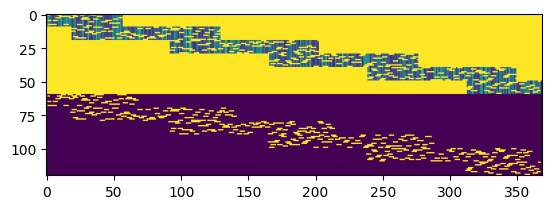

In [245]:
bert_mask = torch.zeros_like(batch).bool()
bert_mask[batch_inds, mut_inds] = 1
res_coverage = bert_mask.sum(dim=0).float()
plt.imshow(torch.cat([batch, bert_mask.int()*32]))
plt.show()

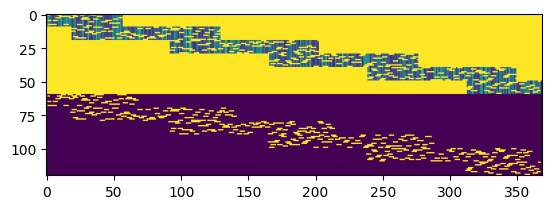

In [ ]:
# (func_cond_finetune/version_2) Func conditioned model, normal bert masking
# (func_cond_finetune/version_4) Func conditioned model, normal bert masking





In [236]:
func_labels = torch.zeros(len(go_terms))
go_term_l = expand_go_terms(csa_df.iloc[0]['GOTerm'], go_dag)
for go_term in go_term_l:
    if go_term in go_ind_map:
        func_labels[go_ind_map[go_term]] = 1

In [39]:
from tqdm.notebook import tqdm
annot_df = csa_df
df_logits = {}
for i, (seq_id, seq, annot_term) in tqdm(enumerate(zip(annot_df['UniprotID'], annot_df['Sequence'], annot_df['GOTerm'])), 
                                 total=len(annot_df)):
    func_labels = torch.zeros(len(go_terms))
    go_term_l = expand_go_terms(annot_term, go_dag)
    for go_term in go_term_l:
        if go_term in go_ind_map:
            func_labels[go_ind_map[go_term]] = 1
    df_logits[seq_id] = get_logits_cond(seq, func_labels, model, batch_size=8, mask_func=mask_perc).float()

bert_map = {k: v[:, 4:24] for k, v in df_logits.items()}
bert_map = {k: v / (v.sum(dim=1, keepdims=True) + 1e-10) for k, v in bert_map.items()}
bert_map = {k: v.numpy() for k, v in bert_map.items()}

annot_mat = gen_annot_mat(annot_df['AnnotatedIndices'], [len(s) for s in annot_df['Sequence']])
seq_len_mask = gen_seq_len_mask(annot_df['Sequence'])
bert_mat = gen_bert_mat(annot_df['UniprotID'], bert_map, max_len=850)
bert_entropy = get_bert_entropy(bert_mat, seq_len_mask)

  0%|          | 0/784 [00:00<?, ?it/s]

In [ ]:
from tqdm.notebook import tqdm
import pickle

ds_labels = ['csa', 'llps', 'elms']
for ds_label, annot_df in zip(ds_labels, [csa_df, llps_df, elms_df]):
    df_logits = {}
    for i, (seq_id, seq) in tqdm(enumerate(zip(annot_df['UniprotID'], annot_df['Sequence'])), 
                                 total=len(annot_df), desc=f'Processing {ds_label}'):
        df_logits[seq_id] = get_logits_esmc(seq, model, batch_size=8, mask_func=mask_perc).float()
    bert_map = {k: v[:, 4:24] for k, v in df_logits.items()}
    bert_map = {k: v / (v.sum(dim=1, keepdims=True) + 1e-10) for k, v in bert_map.items()}
    bert_map = {k: v.numpy() for k, v in bert_map.items()}

    annot_mat = gen_annot_mat(annot_df['AnnotatedIndices'], [len(s) for s in annot_df['Sequence']])
    seq_len_mask = gen_seq_len_mask(annot_df['Sequence'])
    bert_mat = gen_bert_mat(annot_df['UniprotID'], bert_map, max_len=850)
    bert_entropy = get_bert_entropy(bert_mat, seq_len_mask)
    with open(f'eval_files/{ds_label}_esmc.pkl', 'wb') as f:
            pickle.dump({'UniprotID': annot_df['UniprotID'], 'bert_mat': bert_mat, 
                        'seq_len_mask': seq_len_mask, 'bert_entropy': bert_entropy}, f)
    print(f'DS label: {ds_label}')

Processing elms:   0%|          | 0/229 [00:00<?, ?it/s]

DS label: elms
